In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Diamond dataset URL from github 
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.shape

(53940, 10)

### Project questions:
1. Which features are most associated with diamond price?
2. How do color, clarity, karat, cut groups differ in price and value?
3. Which diamonds appear unusually expensive or cheap compared to similar stones?

In [37]:
# Dataset overview:
print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns.tolist())
print("First 5 rows:\n", df.head())
print("Data types:", df.dtypes)
print("Missing values: ", df.isnull().sum())
print("Summary Stat: ", df.describe())

Dataset shape: (53940, 10)
Dataset columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
First 5 rows:
    carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
Data types: carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object
Missing values:  carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Summary Stat:                carat         depth         tab

In [38]:
# Data cleaning
# Remove duplicate values if any
duplicates = df.duplicated().sum()
print("Duplicated rows before cleaning:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicated rows after cleaning:", df.duplicated().sum())
else:
    print("No duplicated rows found.")

Duplicated rows before cleaning: 146
Duplicated rows after cleaning: 0


In [39]:
# Checking for impossible physical measurements
invalid_dimension_mask = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)
invalid_count = invalid_dimension_mask.sum()
print("Number of rows with invalid dimensions:", invalid_count)
if invalid_count > 0:
    print("Rows with invalid dimensions:\n", df[invalid_dimension_mask])
    df = df[~invalid_dimension_mask]

# Convert ordered categorical quality into ordered categories
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True)
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)



Number of rows with invalid dimensions: 19
Rows with invalid dimensions:
        carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25  

In [40]:
# Percnetile based trimming for removing extreme outliers
df_before_trim = df.copy()
depth_low, depth_high = np.percentile(df['depth'], [1, 99])
table_low, table_high = np.percentile(df['table'], [1, 99])

trim_mask = (
    (df['depth'] >= depth_low) & (df['depth'] <= depth_high) &
    (df['table'] >= table_low) & (df['table'] <= table_high)
)

trimmed_out_count = (~trim_mask).sum()
print(f"Number of rows removed by trimming: {trimmed_out_count}")
df = df[trim_mask].copy()

Number of rows removed by trimming: 1317


In [41]:
# Feature engineering: Create a new feature for price per carat
df["volume"] = df["x"] * df["y"] * df["z"]
df["price_per_carat"] = df["price"] / df["carat"]
# Carat category using numpy
carat_bins = [0, 0.5, 1, 1.5, 2, df['carat'].max() + 0.01]
carat_labels =['small', 'medium', 'large', 'very large', 'premium size']
df['carat_category'] = pd.cut(df['carat'], bins=carat_bins, labels=carat_labels, include_lowest=True)
df['face_area'] = df['x'] * df['y']

# Build a custom standardized score using numpy.
df['cut_rank'] = df['cut'].cat.codes + 1 
df['color_rank'] = df['color'].cat.codes + 1
df['clarity_rank'] = df['clarity'].cat.codes + 1

df['quality_score'] = (df['cut_rank'] + df['color_rank'] + df['clarity_rank']) / 3
df['quality_score'] = (df['quality_score'] - df['quality_score'].mean()) / df['quality_score'].std()

In [42]:
# Analysis: Correlation between features and price
correlation_matrix = df.corr(numeric_only=True)
print("Correlation with price:\n", correlation_matrix['price'].sort_values(ascending=False))

Correlation with price:
 price              1.000000
carat              0.924827
price_per_carat    0.914329
volume             0.906101
face_area          0.903964
x                  0.889434
z                  0.871313
y                  0.869038
table              0.136551
depth             -0.015045
cut_rank          -0.052664
clarity_rank      -0.146042
color_rank        -0.172480
quality_score     -0.219344
Name: price, dtype: float64


In [43]:
# Analysis average, mean, by cut, color, clarity
print("Average price by cut:\n", df.groupby('cut')['price'].mean())
print("Average price by color:\n", df.groupby('color')['price'].mean())
print("Average price by clarity:\n", df.groupby('clarity')['price'].mean())

Average price by cut:
 cut
Fair         4504.250927
Good         3877.502699
Very Good    3983.558163
Premium      4579.879557
Ideal        3461.069589
Name: price, dtype: float64
Average price by color:
 color
J    5347.856303
I    5065.678108
H    4468.129024
G    3998.791081
F    3734.908443
E    3070.510992
D    3147.722012
Name: price, dtype: float64
Average price by clarity:
 clarity
I1      3935.824830
SI2     5056.114266
SI1     3989.997406
VS2     3917.357696
VS1     3841.213131
VVS2    3293.735648
VVS1    2525.482692
IF      2880.858837
Name: price, dtype: float64


In [44]:
# Carat category analysis
print("Average price by carat category:\n", df.groupby('carat_category')['price'].mean())

Average price by carat category:
 carat_category
small             838.092533
medium           2809.439812
large            6549.241051
very large      11372.214058
premium size    15098.146644
Name: price, dtype: float64


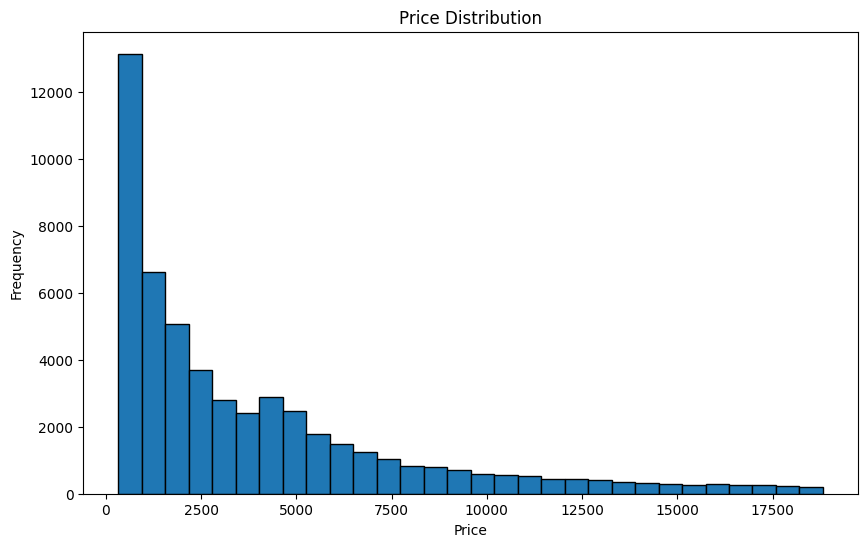

In [45]:
# Visualization
# Price distribution
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

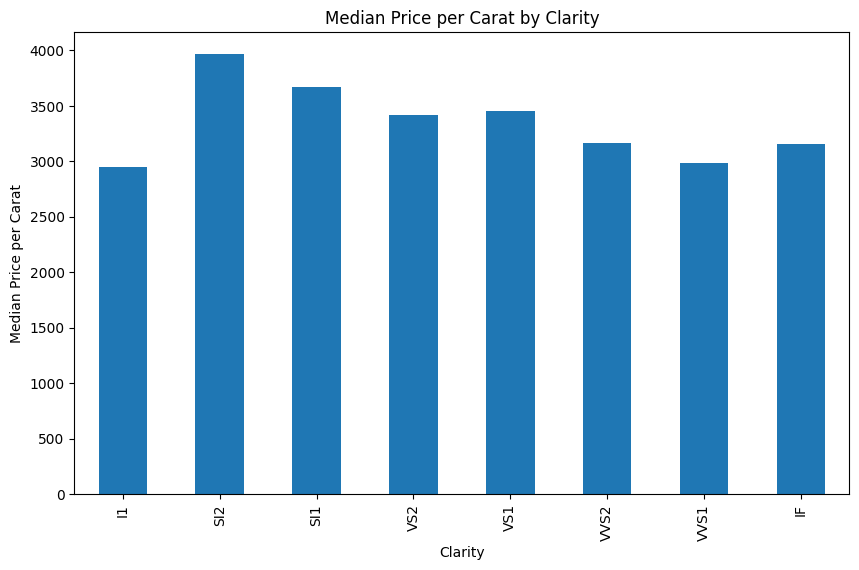

In [46]:
# Median price per carat by clarity
plt.figure(figsize=(10, 6))
median_price_per_carat = df.groupby('clarity')['price_per_carat'].median()
median_price_per_carat.plot(kind='bar')
plt.xlabel('Clarity')
plt.ylabel('Median Price per Carat')
plt.title('Median Price per Carat by Clarity')
plt.show()

<Figure size 1000x600 with 0 Axes>

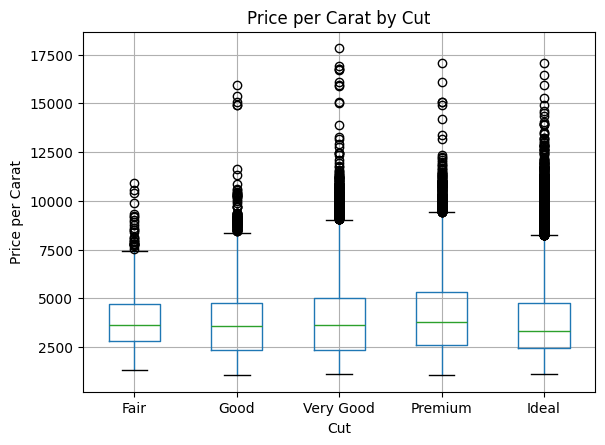

In [47]:
# Box plot of price per carat by cut
plt.figure(figsize=(10, 6))
df.boxplot(column='price_per_carat', by='cut')
plt.xlabel('Cut')
plt.ylabel('Price per Carat')
plt.title('Price per Carat by Cut')
plt.suptitle('')
plt.show()

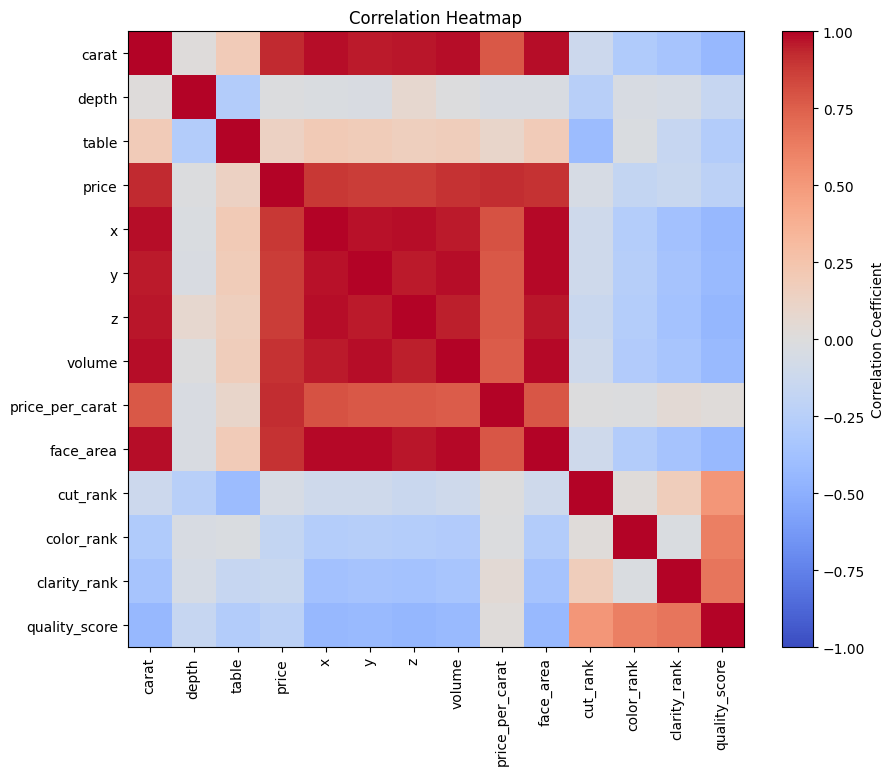

In [48]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()